# Encoder-Only Representation Learning — Lorenz (Single Run)

Trains a causal sequence encoder (Transformer / SSM / TCN) on Lorenz attractors
**without** the downstream JacobianODE, using same-state reconstruction and/or
next-state prediction as self-supervised objectives.

Optional regularisation losses:
- **FNN** – false-nearest-neighbour (Gilpin NeurIPS 2020)
- **Amplification** – noise amplification in embedding space
- **DeCov** – off-diagonal covariance penalty (Cogswell ICLR 2016)

Edit the variable blocks in *Section 2* (data, encoder, training, regularisation)
to quickly experiment with different architectures, latent dimensions, or
regularisation strengths. Default encoder: **SSM** (LRU).

## 1 — Environment Setup

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from hydra.utils import instantiate
import matplotlib.pyplot as plt
import numpy as np

from omegaconf import OmegaConf
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
import sys
import torch
from tqdm.auto import tqdm

# Core pipeline utilities (shared with JacobianODE)
from JacobianODE.jacobians.core import seed_everything
from JacobianODE.jacobians.data import make_trajectories, postprocess_data, create_dataloaders
from JacobianODE.jacobians.training import train_model
from JacobianODE.jacobians.training.logging import log_training_info

# Encoder-only utilities
from JacobianODE.encoder_only.config import load_encoder_config

torch.set_float32_matmul_precision('high')
print(f'PyTorch {torch.__version__}  |  GPUs: {torch.cuda.device_count()}')

PyTorch 2.10.0+cu128  |  GPUs: 1


In [3]:
# ----------------------------------------------------------------
# Paths and W&B settings
# ----------------------------------------------------------------
SAVE_DIR     = "/orcd/data/ekmiller/001/eisenaj/JacobianODE/lightning/encoders"
WANDB_ENTITY = "JacobianODE"
WANDB_PROJECT   = "LorenzPartial_SEQ250BURN50K1D43FNN0.001__Encoder"
WANDB_PROJECT_PATH = f"{WANDB_ENTITY}/{WANDB_PROJECT}"

## 2 — Configuration

Define hyperparameters as variables below, then build overrides from them.  
**Default:** SSM (LRU) encoder. For transformer/tcn, set `MODEL` and adjust encoder vars.

In [4]:
# ----------------------------------------------------------------
# Data hyperparameters
# ----------------------------------------------------------------
NUM_ICS          = 32
N_PERIODS        = 12
PTS_PER_PERIOD   = 100
SEQ_LENGTH       = 100
# SEQ_LENGTH       = 250
OBS_NOISE        = 0.05

# Partial observation (same as hyperparameter tuning notebook)
# OBSERVED_INDICES = [0, 1, 2]   # Observe ALL three Lorenz dimensions; use [0] for x-only
OBSERVED_INDICES = [0]
# N_DELAYS         = 1           # Number of delays for delay embedding (1 = no embedding)
N_DELAYS         = 43
DELAY_SPACING    = 1           # Spacing between delays when N_DELAYS > 1

In [5]:
# ----------------------------------------------------------------
# Encoder / architecture hyperparameters (default: SSM)
# ----------------------------------------------------------------
MODEL = 'ssm'   # ssm | transformer | tcn

N_LATENT = 10

# SSM (LRU) parameters — used when MODEL='ssm'
SSM_D_MODEL    = 128
SSM_D_STATE    = 64
SSM_N_LAYERS   = 3
# SSM_R_MIN      = 0.0
# SSM_R_MAX      = 0.99
SSM_R_MIN = 0.9
SSM_R_MAX = 0.999
SSM_FFN_EXPAND = 4
SSM_DROPOUT    = 0.1

# Transformer parameters — used when MODEL='transformer'
TRANSFORMER_D_MODEL       = 64
TRANSFORMER_N_HEADS       = 4
TRANSFORMER_N_LAYERS      = 3
TRANSFORMER_DIM_FEEDFORWARD = 128
TRANSFORMER_DROPOUT       = 0.1

# TCN parameters — used when MODEL='tcn'
TCN_N_CHANNELS = 64
TCN_KERNEL_SIZE = 7
TCN_N_LAYERS   = 4
TCN_DROPOUT    = 0.1

# Decoder head (shared across architectures)
USE_SAME_STATE_DECODER = True
USE_NEXT_STATE_DECODER = True
DECODER_HIDDEN_DIM    = 128
DECODER_N_LAYERS      = 2
# Burn-in for next-state prediction: skip first N steps (partial obs may need context)
# NEXT_STATE_BURN_IN    = 50
NEXT_STATE_BURN_IN    = 0

# Multi-step ahead prediction:
# K_STEPS_AHEAD=1 means predict x_{t+1} only (original behaviour).
# K_STEPS_AHEAD=k means the next-state decoder jointly predicts [x_{t+1}, ..., x_{t+k}],
# which forces the latent to encode the full dynamical state rather than collapsing.
K_STEPS_AHEAD = 10

# Raw observation dimension for next-state targets.
# When delay embedding is active (N_DELAYS > 1), set this to len(OBSERVED_INDICES)
# so that targets are un-embedded observations: [x_{t+1}, ..., x_{t+k}] without redundancy.
# When N_DELAYS = 1, this equals n_obs and can be left as None (auto-inferred).
N_OBS_PRED = len(OBSERVED_INDICES)  # = raw obs dim, independent of N_DELAYS

In [6]:
# ----------------------------------------------------------------
# Training hyperparameters
# ----------------------------------------------------------------
BATCH_SIZE               = 32
LEARNING_RATE            = 1e-4
MAX_EPOCHS               = 200
LIMIT_TRAIN_BATCHES      = 200
EARLY_STOPPING_PATIENCE  = 2     # Patience for percent-thresh early stopping
PERCENT_THRESH           = 0.01  # Min. percent improvement required (percent_thresh mode)

# ----------------------------------------------------------------
# Regularisation weights (0 to disable)
# ----------------------------------------------------------------
# FNN_WEIGHT           = 0.0   # FNN latent-geometry regulariser (Gilpin NeurIPS 2020)
FNN_WEIGHT           = 0.001
# FNN_NORMALIZE        = False # Normalize FNN loss by activation variance
FNN_NORMALIZE        = True
# FNN_ELEMENTWISE_REG  = False # Elementwise FNN: E[W*A^2] vs E[W]*E[A^2]
FNN_ELEMENTWISE_REG  = True
AMPLIFICATION_WEIGHT = 0.0   # Noise amplification regulariser
DECOV_WEIGHT         = 0.0   # DeCov off-diagonal covariance penalty (Cogswell ICLR 2016)

In [7]:
# Format list-valued overrides without spaces so they double as valid Hydra CLI args
_obs_idx_str = str(list(OBSERVED_INDICES)).replace(' ', '')

# Build overrides from variables (matches hyperparameter tuning notebook pattern)
overrides = [
    # --- Model: SSM (LRU) encoder ---
    f"model={MODEL}",
    f"++model.encoder.n_latent={N_LATENT}",
    f"++model.use_same_state_decoder={str(USE_SAME_STATE_DECODER).lower()}",
    f"++model.use_next_state_decoder={str(USE_NEXT_STATE_DECODER).lower()}",
    f"++model.decoder_hidden_dim={DECODER_HIDDEN_DIM}",
    f"++model.decoder_n_layers={DECODER_N_LAYERS}",
    f"++model.next_state_burn_in={NEXT_STATE_BURN_IN}",
    f"++model.k_steps_ahead={K_STEPS_AHEAD}",
    f"++model.n_obs_pred={N_OBS_PRED}",
]

# Architecture-specific encoder overrides
if MODEL == 'ssm':
    overrides.extend([
        f"++model.encoder.d_model={SSM_D_MODEL}",
        f"++model.encoder.d_state={SSM_D_STATE}",
        f"++model.encoder.n_layers={SSM_N_LAYERS}",
        f"++model.encoder.r_min={SSM_R_MIN}",
        f"++model.encoder.r_max={SSM_R_MAX}",
        f"++model.encoder.ffn_expand={SSM_FFN_EXPAND}",
        f"++model.encoder.dropout={SSM_DROPOUT}",
    ])
elif MODEL == 'transformer':
    overrides.extend([
        f"++model.encoder.d_model={TRANSFORMER_D_MODEL}",
        f"++model.encoder.n_heads={TRANSFORMER_N_HEADS}",
        f"++model.encoder.n_layers={TRANSFORMER_N_LAYERS}",
        f"++model.encoder.dim_feedforward={TRANSFORMER_DIM_FEEDFORWARD}",
        f"++model.encoder.dropout={TRANSFORMER_DROPOUT}",
    ])
elif MODEL == 'tcn':
    overrides.extend([
        f"++model.encoder.n_channels={TCN_N_CHANNELS}",
        f"++model.encoder.kernel_size={TCN_KERNEL_SIZE}",
        f"++model.encoder.n_layers={TCN_N_LAYERS}",
        f"++model.encoder.dropout={TCN_DROPOUT}",
    ])

overrides.extend([
    # --- Paths and W&B (from Section 2 variables) ---
    f"training.logger.save_dir={SAVE_DIR}",
    f"wandb_entity={WANDB_ENTITY}",
    f"wandb_project={WANDB_PROJECT}",
    # --- Regularisation ---
    f"++training.lightning.fnn_weight={FNN_WEIGHT}",
    f"++training.lightning.fnn_normalize={str(FNN_NORMALIZE).lower()}",
    f"++training.lightning.fnn_elementwise_regularization={str(FNN_ELEMENTWISE_REG).lower()}",
    f"++training.lightning.amplification_weight={AMPLIFICATION_WEIGHT}",
    f"++training.lightning.decov_weight={DECOV_WEIGHT}",
    # --- Training ---
    f"++training.batch_size={BATCH_SIZE}",
    f"++training.lightning.optimizer_kwargs.lr={LEARNING_RATE}",
    f"++training.trainer_params.max_epochs={MAX_EPOCHS}",
    f"++training.trainer_params.limit_train_batches={LIMIT_TRAIN_BATCHES}",
    f"++training.early_stopping.early_stopping_patience={EARLY_STOPPING_PATIENCE}",
    f"++training.early_stopping.percent_thresh={PERCENT_THRESH}",
    # --- Data ---
    f"++data.trajectory_params.num_ics={NUM_ICS}",
    f"++data.trajectory_params.n_periods={N_PERIODS}",
    f"++data.trajectory_params.pts_per_period={PTS_PER_PERIOD}",
    f"++data.train_test_params.seq_length={SEQ_LENGTH}",
    f"++data.postprocessing.obs_noise={OBS_NOISE}",
    # --- Partial observation / delay embedding ---
    f"++data.train_test_params.delay_embedding_params.observed_indices={_obs_idx_str}",
    f"++data.train_test_params.delay_embedding_params.n_delays={N_DELAYS}",
    f"++data.train_test_params.delay_embedding_params.delay_spacing={DELAY_SPACING}",
])

cfg = load_encoder_config(overrides=overrides)
print(OmegaConf.to_yaml(cfg))

wandb_entity: JacobianODE
wandb_project: LorenzPartial_SEQ250BURN50K1D43FNN0.001__Encoder
training:
  batch_size: 32
  run_number: 0
  lightning:
    _target_: JacobianODE.encoder_only.model.LitEncoderDecoder
    optimizer: AdamW
    optimizer_kwargs:
      lr: 0.0001
      weight_decay: 0.0001
    use_scheduler: true
    min_lr: 1.0e-06
    lr_scheduler_patience: 10
    lr_scheduler_factor: 0.5
    gradient_clip_val: 1.0
    gradient_clip_algorithm: norm
    same_state_weight: 1.0
    next_state_weight: 1.0
    fnn_weight: 0.001
    fnn_normalize: true
    fnn_elementwise_regularization: true
    amplification_weight: 0.0
    decov_weight: 0.0
    amplification_n_neighbors: 10
    amplification_max_T: 5
  logger:
    _target_: pytorch_lightning.loggers.WandbLogger
    save_dir: /orcd/data/ekmiller/001/eisenaj/JacobianODE/lightning/encoders
    log_model: true
  trainer_params:
    limit_train_batches: 200
    limit_val_batches: 100
    max_epochs: 200
    accumulate_grad_batches: 4
  

## 3 — Generate and Preprocess Data

In [8]:
seed_everything(cfg.data.flow.random_state)

eq, sol, dt = make_trajectories(cfg)
values_raw = sol['values']

result = postprocess_data(cfg, values_raw)
values = result.values
mu, sigma = result.mu, result.sigma
noise_scale_factor = result.noise_scale_factor

# Store postprocessing metadata on config
cfg.data.postprocessing.noise_scale_factor = noise_scale_factor
cfg.data.postprocessing.mu = mu
cfg.data.postprocessing.sigma = sigma

print(f'Data shape: {values.shape}  (trajectories × time × dims)')
print(f'dt = {dt:.4f}')

Data shape: (32, 1200, 3)  (trajectories × time × dims)
dt = 0.0150


## 4 — DataLoaders

In [9]:
train_dl, val_dl, test_dl, trajs = create_dataloaders(cfg, values, verbose=True, return_full_obs=True)

n_obs = trajs['train_trajs'].sequence.shape[-1]
print(f'n_obs = {n_obs}')

Sequence Indices:   0%|          | 0/1058 [00:00<?, ?it/s]

Train dataset shape: torch.Size([23276, 100, 43])
Validation dataset shape: torch.Size([7406, 100, 43])
Test dataset shape: torch.Size([3174, 100, 43])
Train trajectories dataset shape: torch.Size([22, 1158, 43])
Validation trajectories dataset shape: torch.Size([7, 1158, 43])
Test trajectories dataset shape: torch.Size([3, 1158, 43])
n_obs = 43


## 5 — Build Model

In [10]:
seed_everything(cfg.data.flow.random_state + cfg.training.run_number + 1)

# Instantiate the sequence encoder; inject runtime n_input
encoder = instantiate(cfg.model.encoder, n_input=n_obs)

# Instantiate the Lightning wrapper, merging model-level and training-level params
lit_model = instantiate(
    cfg.training.lightning,
    encoder=encoder,
    n_obs=n_obs,
    context_margin=int(cfg.model.get('context_margin', 0)),
    next_state_burn_in=int(cfg.model.get('next_state_burn_in', 0)),
    use_same_state_decoder=bool(cfg.model.get('use_same_state_decoder', True)),
    use_next_state_decoder=bool(cfg.model.get('use_next_state_decoder', False)),
    decoder_hidden_dim=int(cfg.model.get('decoder_hidden_dim', 128)),
    decoder_n_layers=int(cfg.model.get('decoder_n_layers', 2)),
    k_steps_ahead=int(cfg.model.get('k_steps_ahead', 1)),
    n_obs_pred=cfg.model.get('n_obs_pred', None),
)

total_params = sum(p.numel() for p in lit_model.parameters())
print(f'Model: {type(encoder).__name__}  |  n_latent={lit_model.n_latent}  |  params={total_params:,}')
print(f'k_steps_ahead={lit_model.k_steps_ahead}  |  n_obs_pred={lit_model.n_obs_pred}')

Model: SSMSequenceEncoder  |  n_latent=10  |  params=792,255
k_steps_ahead=10  |  n_obs_pred=1


## 6 — W&B Setup and Training

In [11]:
import wandb
from JacobianODE.encoder_only.run_encoder import _make_run_name, _make_project
from JacobianODE.jacobians.training.logging import _deduplicate_run_name

# Use config overrides when set; fall back to auto-generated / env
project = cfg.get("wandb_project") or _make_project(cfg)
entity  = cfg.get("wandb_entity") or os.environ.get("WANDB_ENTITY", None)
name    = _make_run_name(cfg)

# Uncomment to auto-deduplicate run names (requires W&B API access):
# name = _deduplicate_run_name(name, project, entity, log=None)

print(f'W&B project : {project}')
print(f'W&B entity  : {entity}')
print(f'Run name    : {name}')

W&B project : LorenzPartial_SEQ250BURN50K1D43FNN0.001__Encoder
W&B entity  : JacobianODE
Run name    : Lorenz__SSMSequenceEncoder__n_latent_10__same__next__fnn_weight_0.001__run_0


In [12]:
train_model(
    cfg,
    lit_model,
    train_dl,
    val_dl,
    name=name,
    project=project,
    entity=entity,
)

wandb: WARNING The anonymous setting has no effect and will be removed in a future version.
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/eisenaj/.netrc.
wandb: Currently logged in as: adamjeisen (JacobianODE) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


/home/eisenaj/code/JacobianODE/.venv/lib64/python3.12/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/eisenaj/code/JacobianODE/.venv/lib64/python3.1 ...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name               | Type               | Params | Mode  | FLOPs
--------------------------------------------------------------------------
0 | encoder            | SSMSequenceEncoder | 749 K  | train | 0    
1 | same_state_decoder | Sequential         | 23.5 K | train | 0    
2 | next_

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/eisenaj/code/JacobianODE/.venv/lib64/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▄▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇███
mean val loss,█▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
percent_improvement,█▅▃▄▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/fnn_loss,▃▁▂▄▆▆▆▆▇▇▇▇▇▇██▇█████████
train/latent_utilization,▁▃▄▆███▇▇▇▇▇▇▇▇█▇█████████
train/loss,█▃▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/next_state_loss,█▃▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/next_state_r2,▁▆▇███████████████████████
train/same_state_loss,█▄▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/same_state_r2,▁▅▇▇██████████████████████
+11,...


## 6a — Load from W&B Run (optional)

**Run this instead of Section 6** if you want to load a previously trained model.
Regenerates all data and dataloaders from the run's config so hyperparameters match.

In [ ]:
# import wandb, types
# run_id = "iu8cq3qx"
# wandb.run = types.SimpleNamespace(id=run_id)

In [13]:
# Set to a W&B run ID to load that model; leave None to use the model from Section 6
# To get the run ID of the model that just ran, you can access it via wandb.run.id after training:
# Example:
# LOAD_FROM_RUN_ID = wandb.run.id if wandb.run is not None else None
LOAD_FROM_RUN_ID = wandb.run.id if hasattr(wandb, "run") and wandb.run is not None else None  # e.g. "daki8tyx" or "abc123def456"

if LOAD_FROM_RUN_ID is not None:
    from JacobianODE.jacobians.checkpoints import load_run

    run, cfg, eq, dt, values, train_dl, val_dl, test_dl, trajs, lit_model = load_run(
        project=WANDB_PROJECT_PATH,  # entity/project for wandb api
        run_id=LOAD_FROM_RUN_ID,
        generate_data=True,
        verbose=True,
    )
    n_obs = trajs["train_trajs"].sequence.shape[-1]
    print(f"Loaded run {LOAD_FROM_RUN_ID} | n_obs={n_obs} | data regenerated from config")
else:
    print("LOAD_FROM_RUN_ID is None — using model from Section 6 (train or build)")

LOAD_FROM_RUN_ID is None — using model from Section 6 (train or build)


## 7 — Evaluation and Visualisation

In [14]:
# ---- Reconstruction quality on a test batch ----
lit_model.eval()
# device = next(lit_model.parameters()).device
device = "cuda" if torch.cuda.is_available() else "cpu"
lit_model.to(device)

torch.manual_seed(42)
N_SAMPLES = 128
# randomly sample N_SAMPLES from test_dl.dataset.sequence
x_batch = test_dl.dataset.sequence[np.random.choice(test_dl.dataset.sequence.shape[0], N_SAMPLES, replace=False)]
x_batch = x_batch.to(device)

k = lit_model.k_steps_ahead
n_pred = lit_model.n_obs_pred

with torch.no_grad():
    z = lit_model.encoder(x_batch)                      # (B, T, N_LATENT)

    cm = lit_model.context_margin
    x_valid = x_batch[:, cm:]
    z_valid = z[:, cm:]

    if lit_model.use_same_state_decoder:
        x_hat = lit_model.same_state_decoder(z_valid)   # (B, T', D_obs)
    if lit_model.use_next_state_decoder:
        # Output shape: (B, T'-k, k * n_obs_pred); extract first step for vis
        x_next_hat_full = lit_model.next_state_decoder(z_valid[:, :-k])  # (B, T'-k, k*n_pred)
        x_next_hat = x_next_hat_full.reshape(*x_next_hat_full.shape[:2], k, n_pred)[:, :, 0, :]  # (B, T'-k, n_pred)

print(f'x_batch shape : {x_batch.shape}')
print(f'z shape       : {z.shape}')
if lit_model.use_same_state_decoder:
    print(f'x_hat shape   : {x_hat.shape}')
if lit_model.use_next_state_decoder:
    print(f'x_next_hat shape (all steps) : {x_next_hat_full.shape}  (k={k}, n_obs_pred={n_pred})')
    print(f'x_next_hat shape (step 1)    : {x_next_hat.shape}')

x_batch shape : torch.Size([128, 100, 43])
z shape       : torch.Size([128, 100, 10])
x_hat shape   : torch.Size([128, 100, 43])
x_next_hat shape (all steps) : torch.Size([128, 90, 10])  (k=10, n_obs_pred=1)
x_next_hat shape (step 1)    : torch.Size([128, 90, 1])


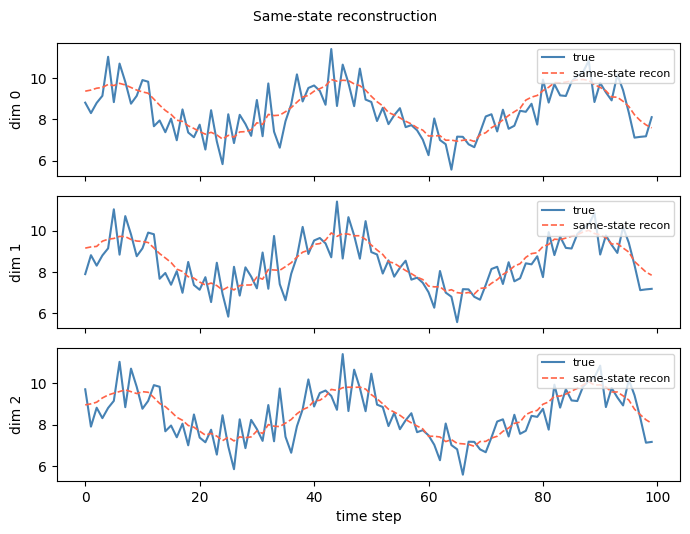

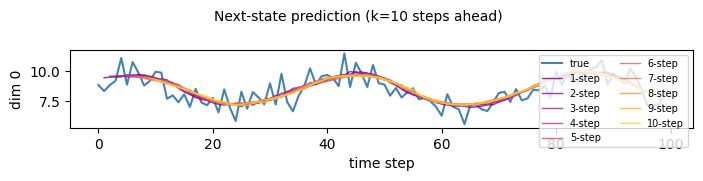

In [15]:
# ----------------------------------------------------------------
# Plot 1: Same-state reconstruction — true vs predicted (single trajectory)
# Recompute x_hat from z_valid so lengths match (x_hat can be overwritten by later cells)
# ----------------------------------------------------------------
if lit_model.use_same_state_decoder:
    batch_idx = 0
    device = next(lit_model.parameters()).device
    x_hat_plot = lit_model.same_state_decoder(z_valid.to(device))  # guarantee same shape as x_valid
    n_dims = min(x_valid.shape[-1], 3)
    fig, axes = plt.subplots(n_dims, 1, figsize=(7, 1.8 * n_dims), sharex=True)
    if n_dims == 1:
        axes = [axes]
    x_np = x_valid[batch_idx].cpu().numpy()
    xh_np = x_hat_plot[batch_idx].detach().cpu().numpy()
    for d, ax in enumerate(axes):
        ax.plot(x_np[:, d], label='true', lw=1.5, color='steelblue')
        ax.plot(xh_np[:, d], label='same-state recon', lw=1.2, color='tomato', ls='--')
        ax.set_ylabel(f'dim {d}')
        ax.legend(loc='upper right', fontsize=8)
    axes[-1].set_xlabel('time step')
    fig.suptitle('Same-state reconstruction', fontsize=10)
    plt.tight_layout()
    plt.show()

# ----------------------------------------------------------------
# Plot 2: k-step ahead predictions — 1-step, 2-step, ..., k-step
# x_next_hat_full: (B, T'-k, k, n_obs_pred); step s predicts x_{t+s}
# ----------------------------------------------------------------
if lit_model.use_next_state_decoder:
    batch_idx = 0
    x_full = x_next_hat_full.reshape(
        *x_next_hat_full.shape[:2], k, n_pred
    )  # (B, T'-k, k, n_pred)
    T_pred = x_full.shape[1]
    n_dims_pred = min(n_pred, 3)
    fig, axes = plt.subplots(n_dims_pred, 1, figsize=(7, 1.8 * n_dims_pred), sharex=True)
    if n_dims_pred == 1:
        axes = [axes]
    cmap = plt.cm.plasma(np.linspace(0.2, 0.9, k))
    for d, ax in enumerate(axes):
        # True trajectory (first n_pred dims of x_valid)
        x_true = x_valid[batch_idx, :, d].cpu().numpy()
        ax.plot(x_true, label='true', lw=1.5, color='steelblue')
        for s in range(k):
            # (s+1)-step ahead: predict x_{t+s+1} from z_t; plotted at s+1, s+2, ...
            pred = x_full[batch_idx, :, s, d].cpu().numpy()
            t_axis = np.arange(s + 1, s + 1 + T_pred)
            ax.plot(t_axis, pred, label=f'{s+1}-step', lw=1, alpha=0.8, color=cmap[s])
        ax.set_ylabel(f'dim {d}')
        ax.legend(loc='upper right', fontsize=7, ncol=2)
    axes[-1].set_xlabel('time step')
    fig.suptitle(f'Next-state prediction (k={k} steps ahead)', fontsize=10)
    plt.tight_layout()
    plt.show()

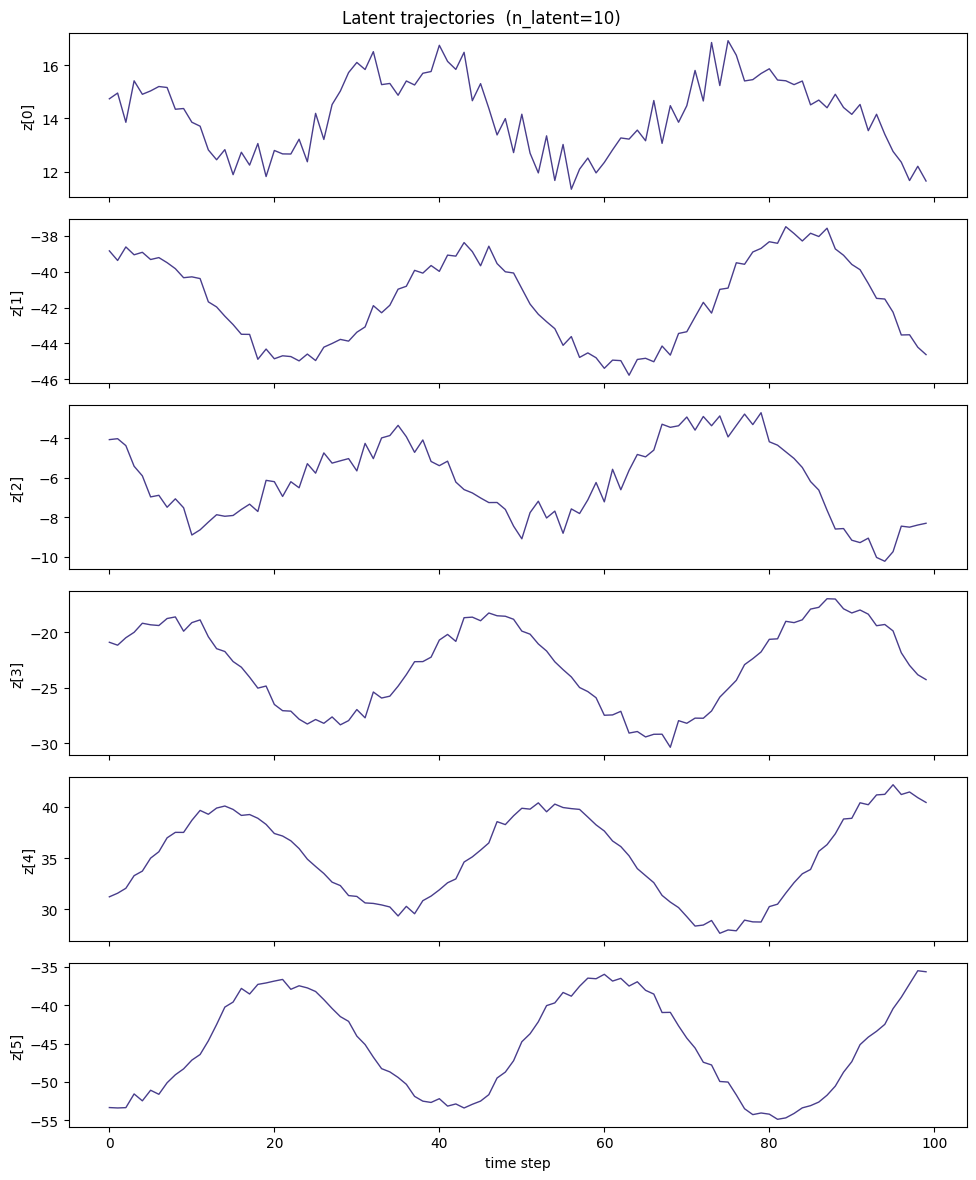

In [16]:
# ---- Latent trajectory visualisation (first 3 dims) ----
z_np = z_valid[0].cpu().numpy()   # (T', N_LATENT)

n_show = min(z_np.shape[-1], 6)
fig, axes = plt.subplots(n_show, 1, figsize=(10, 2.0 * n_show), sharex=True)
if n_show == 1:
    axes = [axes]
for i, ax in enumerate(axes):
    ax.plot(z_np[:, i], lw=1, color='darkslateblue')
    ax.set_ylabel(f'z[{i}]')
axes[-1].set_xlabel('time step')
fig.suptitle(f'Latent trajectories  (n_latent={lit_model.n_latent})', fontsize=12)
plt.tight_layout()
plt.show()

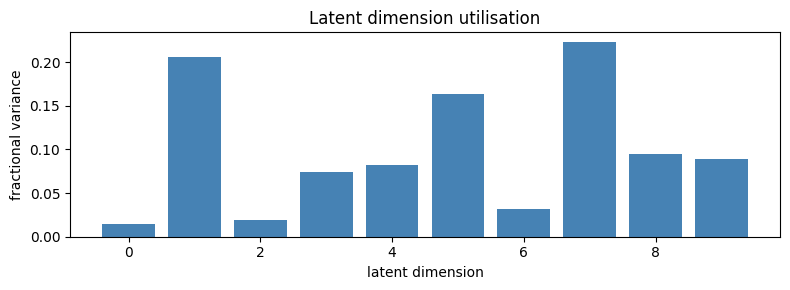

Entropy-based utilization: 0.887  (1.0 = uniform, 0.0 = single dim)


In [17]:
# ---- Per-dimension variance (latent utilisation) ----
z_all = z_valid.cpu().numpy()   # (B, T', N_LATENT)
dim_var = z_all.reshape(-1, z_all.shape[-1]).var(axis=0)

fig, ax = plt.subplots(figsize=(8, 3))
ax.bar(range(len(dim_var)), dim_var / dim_var.sum(), color='steelblue')
ax.set_xlabel('latent dimension')
ax.set_ylabel('fractional variance')
ax.set_title('Latent dimension utilisation')
plt.tight_layout()
plt.show()

import math
p = dim_var / dim_var.sum()
entropy = -np.sum(p * np.log(p + 1e-10))
utilization = entropy / math.log(lit_model.n_latent)
print(f'Entropy-based utilization: {utilization:.3f}  (1.0 = uniform, 0.0 = single dim)')

## 8 — PCA & Participation Ratio on Test Set

Compute latents for the full test dataset, PCA participation ratio (PR), and PC1×PC2 plots.

  0%|          | 0/3 [00:00<?, ?it/s]

torch.Size([8, 1158, 10])
torch.Size([8, 1158, 43])
torch.Size([8, 1158, 10])
torch.Size([8, 1158, 43])
torch.Size([6, 1158, 10])
torch.Size([6, 1158, 43])
Participation ratio — Latents: 1.487  |  True state, full obs (Train): 1.730


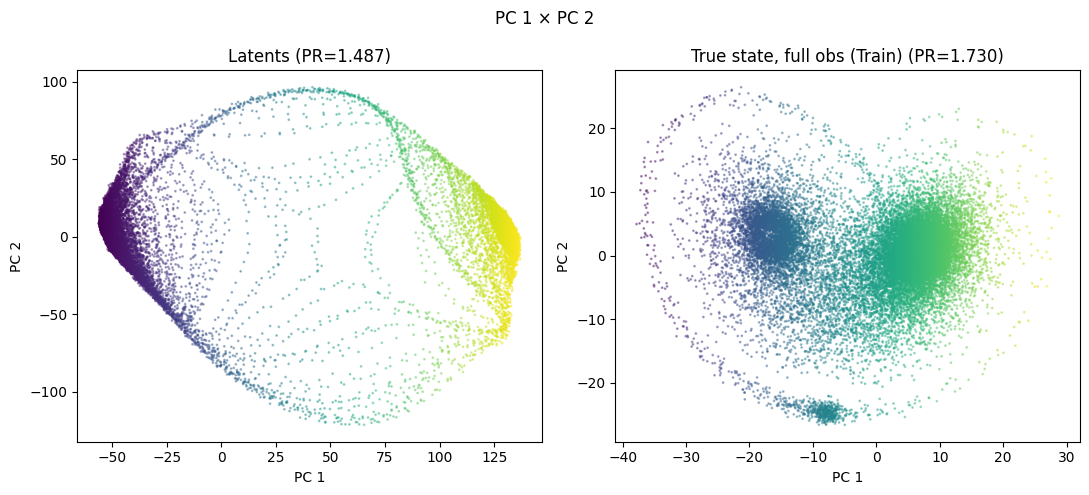

In [18]:
from sklearn.decomposition import PCA

lit_model.eval()
device = "cuda" if torch.cuda.is_available() else "cpu"
lit_model.to(device)
cm = lit_model.context_margin

# ---- Option to use either test or train dataset ----
use_train = True  # Set to True to use train set, False to use test set

if use_train:
    traj_key = "train_trajs"
    full_obs_key = "train_trajs_full"
    label_prefix = "Train"
else:
    traj_key = "test_trajs"
    full_obs_key = "test_trajs_full"
    label_prefix = "Test"

# Run encoder on full trajectories (no chopping)
trajs_obs = trajs[traj_key].sequence   # (N_traj, T, D_obs)
trajs_full = trajs[full_obs_key].sequence  # (N_traj, T, D_full)

batch_traj = 8
all_latents = []
all_decoded = []
with torch.no_grad():
    for i in tqdm(range(0, trajs_obs.shape[0], batch_traj)):
        x = torch.as_tensor(trajs_obs[i : i + batch_traj]).float().to(device)
        z = lit_model.encoder(x)[:, cm:]  # (B, T - cm, n_latent)
        print(z.shape)
        # decoder
        x_hat = lit_model.same_state_decoder(z)
        print(x_hat.shape)
        all_latents.append(z.cpu())
        all_decoded.append(x_hat.cpu())
Z = torch.cat(all_latents, dim=0).reshape(-1, lit_model.n_latent).numpy()
X_hat = torch.cat(all_decoded, dim=0).numpy()

# True state: full-obs flattened, aligned with latent positions (skip first cm timesteps)
trajs_full_arr = np.asarray(trajs_full)
X_true = trajs_full_arr[:, cm:, :].reshape(-1, trajs_full_arr.shape[-1])
true_label = f"True state, full obs ({label_prefix})"

# 3. Participation ratio (PR) from PCA eigenvalues
def participation_ratio(X):
    X_flat = X.reshape(-1, X.shape[-1])
    cov = np.cov(X_flat, rowvar=False)
    eigvals = np.linalg.eigvalsh(cov)
    return (eigvals.sum()) ** 2 / ((eigvals**2).sum() + 1e-12)

pr_latent = participation_ratio(Z)
pr_true = participation_ratio(X_true)
print(f"Participation ratio — Latents: {pr_latent:.3f}  |  {true_label}: {pr_true:.3f}")

# 4. PCA for plotting
pca_latent = PCA(n_components=2).fit(Z)
pca_true = PCA(n_components=2).fit(X_true)
Z_pc = pca_latent.transform(Z)
X_true_pc = pca_true.transform(X_true)

# 5. Side-by-side PC1×PC2 plots
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
axes[0].scatter(Z_pc[:, 0], Z_pc[:, 1], s=1, alpha=0.4, c=Z_pc[:, 0], cmap="viridis")
axes[0].set_xlabel("PC 1")
axes[0].set_ylabel("PC 2")
axes[0].set_title(f"Latents (PR={pr_latent:.3f})")
axes[1].scatter(X_true_pc[:, 0], X_true_pc[:, 1], s=1, alpha=0.4, c=X_true_pc[:, 0], cmap="viridis")
axes[1].set_xlabel("PC 1")
axes[1].set_ylabel("PC 2")
axes[1].set_title(f"{true_label} (PR={pr_true:.3f})")
fig.suptitle("PC 1 × PC 2", fontsize=12)
plt.tight_layout()
plt.show()

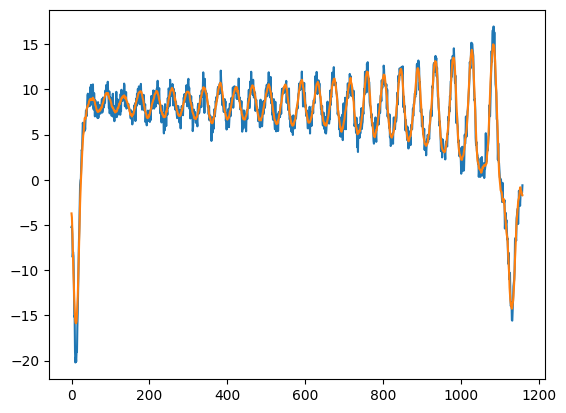

In [19]:
traj_ind = 11
ind = 8
plt.plot(trajs_obs[:, cm:, :][traj_ind, :, ind])
plt.plot(X_hat[traj_ind, :, ind])
plt.show()


Using device: cuda
Note: X_true has 26400 pts, Z has 25476 pts — truncating to 25476
Normalized FNN loss — True state:  0.049222
Normalized FNN loss — Latents:     0.086995


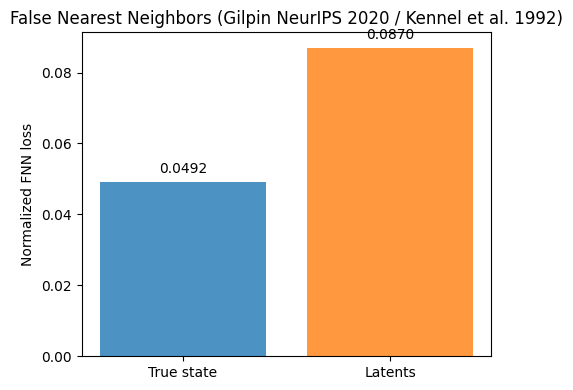

In [20]:
from JacobianODE.fnn import loss_false
from sklearn.decomposition import PCA
import torch

# Set device for computation (GPU if available, else CPU)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# DEVICE = "cpu"
print(f"Using device: {DEVICE}")

# Whether to project onto PCA bases before computing FNN (makes comparison more comparable)
USE_PCA_PROJECTION = True
USE_NORMALIZE = True
ELEMENTWISE_REGULARIZATION = True

# Flatten and convert to torch (Z, X_true from PCA cell above), and move to device
X_true_t   = torch.from_numpy(X_true).float().to(DEVICE)    # (N, 3)
X_latent_t = torch.from_numpy(Z).float().to(DEVICE)         # (N, n_latent)

# Optional subsample for large N (FNN is O(N^2))
# N_max = len(X_true_t)
N_max = 2048
# Use min length so idx is valid for BOTH tensors (X_true and Z can differ if trajs are misaligned)
n = min(len(X_true_t), len(X_latent_t))
if len(X_true_t) != len(X_latent_t):
    print(f"Note: X_true has {len(X_true_t)} pts, Z has {len(X_latent_t)} pts — truncating to {n}")
if n > N_max:
    rng = np.random.default_rng(42)
    idx = rng.choice(n, N_max, replace=False)
    X_true_t   = X_true_t[idx]
    X_latent_t = X_latent_t[idx]
elif n < len(X_true_t) or n < len(X_latent_t):
    X_true_t   = X_true_t[:n]
    X_latent_t = X_latent_t[:n]

if USE_PCA_PROJECTION:
    # Move tensors to CPU for sklearn compatibility, then back to device
    X_true_np = X_true_t.detach().cpu().numpy()
    X_latent_np = X_latent_t.detach().cpu().numpy()
    pca_true = PCA(n_components=X_true_np.shape[1]).fit(X_true_np)
    pca_latent = PCA(n_components=X_latent_np.shape[1]).fit(X_latent_np)
    X_true_t   = torch.from_numpy(pca_true.transform(X_true_np)).float().to(DEVICE)
    X_latent_t = torch.from_numpy(pca_latent.transform(X_latent_np)).float().to(DEVICE)

with torch.no_grad():
    fnn_true, reg_true   = loss_false(X_true_t, k=1, normalize=USE_NORMALIZE, return_fnn_weights=True, elementwise_regularization=ELEMENTWISE_REGULARIZATION)
    fnn_latent, reg_latent = loss_false(X_latent_t, k=1, normalize=USE_NORMALIZE, return_fnn_weights=True, elementwise_regularization=ELEMENTWISE_REGULARIZATION)
    fnn_true = fnn_true.item()
    fnn_latent = fnn_latent.item()
    reg_true = reg_true.detach().cpu().numpy() if hasattr(reg_true, 'detach') else reg_true
    reg_latent = reg_latent.detach().cpu().numpy() if hasattr(reg_latent, 'detach') else reg_latent

print(f"{'Normalized' if USE_NORMALIZE else 'Unnormalized'} FNN loss — True state:  {fnn_true:.6f}")
print(f"{'Normalized' if USE_NORMALIZE else 'Unnormalized'} FNN loss — Latents:     {fnn_latent:.6f}")

fig, ax = plt.subplots(figsize=(5, 4))
labels = ["True state", "Latents"]
values = [fnn_true, fnn_latent]
bars = ax.bar(labels, values, color=["C0", "C1"], alpha=0.8)
ax.set_ylabel("Normalized FNN loss")
ax.set_title("False Nearest Neighbors (Gilpin NeurIPS 2020 / Kennel et al. 1992)")
for bar, val in zip(bars, values):
    ax.annotate(f"{val:.4f}", xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 4), textcoords="offset points", ha="center", va="bottom")
plt.tight_layout()
plt.show()